# 1. Data Exploration
Explore the pushup video dataset — understand the structure, video properties, and visualize sample frames.

**Goal:** Understand what we're working with before building a person detector that identifies the **closest person** in each frame.

In [56]:
# Install dependencies if needed
import subprocess, sys
def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

for pkg in ['opencv-python', 'matplotlib', 'pandas', 'tqdm']:
    install(pkg)
print('Dependencies ready.')

Dependencies ready.


In [57]:
import cv2
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from tqdm import tqdm

# ── Paths ─────────────────────────────────────────────────────────────────────
ROOT        = Path('..').resolve()          # pushup_judge/
DATA_DIR    = ROOT / 'data'
CORRECT_DIR = DATA_DIR / 'correct_form'
WRONG_DIR   = DATA_DIR / 'wrong_form'

print('Root       :', ROOT)
print('Correct dir:', CORRECT_DIR)
print('Wrong dir  :', WRONG_DIR)

Root       : /Users/haleytran/Downloads/pushup_judge
Correct dir: /Users/haleytran/Downloads/pushup_judge/data/correct_form
Wrong dir  : /Users/haleytran/Downloads/pushup_judge/data/wrong_form


## 1.1 Dataset Overview

In [58]:
def collect_videos(directory: Path, label: str) -> list[dict]:
    videos = []
    for p in sorted(directory.glob('*.mp4')):
        videos.append({'path': str(p), 'filename': p.name, 'label': label})
    return videos

correct_videos = collect_videos(CORRECT_DIR, 'correct_form')
wrong_videos   = collect_videos(WRONG_DIR,   'wrong_form')
all_videos     = correct_videos + wrong_videos

print(f'Correct form videos : {len(correct_videos)}')
print(f'Wrong form videos   : {len(wrong_videos)}')
print(f'Total videos        : {len(all_videos)}')

Correct form videos : 76
Wrong form videos   : 76
Total videos        : 152


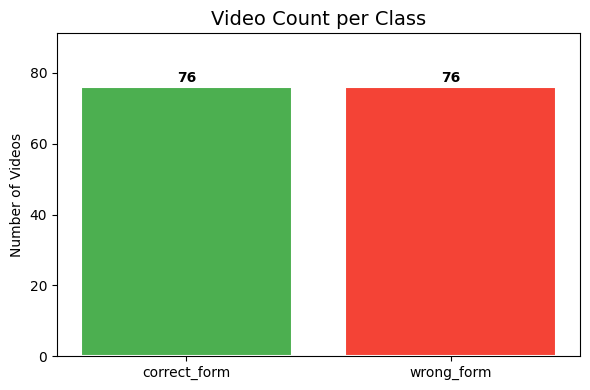

In [59]:
# Class distribution bar chart
labels  = ['correct_form', 'wrong_form']
counts  = [len(correct_videos), len(wrong_videos)]
colors  = ['#4CAF50', '#F44336']

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, counts, color=colors, edgecolor='white', linewidth=1.5)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            str(count), ha='center', va='bottom', fontweight='bold')
ax.set_title('Video Count per Class', fontsize=14)
ax.set_ylabel('Number of Videos')
ax.set_ylim(0, max(counts) * 1.2)
plt.tight_layout()
plt.show()

## 1.2 Video Properties Analysis

In [60]:
def get_video_info(video_path: str) -> dict:
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return {}
    fps         = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width       = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height      = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    duration    = frame_count / fps if fps > 0 else 0
    file_size   = os.path.getsize(video_path) / (1024 * 1024)  # MB
    cap.release()
    return {
        'fps': round(fps, 2),
        'frame_count': frame_count,
        'width': width,
        'height': height,
        'duration_sec': round(duration, 2),
        'resolution': f'{width}x{height}',
        'file_size_mb': round(file_size, 2)
    }

# Build metadata dataframe
records = []
for v in tqdm(all_videos, desc='Reading video metadata'):
    info = get_video_info(v['path'])
    records.append({**v, **info})

df = pd.DataFrame(records)
df.head()

Reading video metadata: 100%|██████████| 152/152 [00:00<00:00, 178.90it/s]


,path,filename,label,fps,frame_count,width,height,duration_sec,resolution,file_size_mb
0,/Users/haleytran/Downloads/pushup_judge/data/c...,Copy of push up 1.mp4,correct_form,25.0,61,640,360,2.44,640x360,0.08
1,/Users/haleytran/Downloads/pushup_judge/data/c...,Copy of push up 100.mp4,correct_form,25.0,124,640,360,4.96,640x360,0.09
2,/Users/haleytran/Downloads/pushup_judge/data/c...,Copy of push up 101.mp4,correct_form,25.0,77,640,360,3.08,640x360,0.08
3,/Users/haleytran/Downloads/pushup_judge/data/c...,Copy of push up 102.mp4,correct_form,25.0,83,640,360,3.32,640x360,0.08
4,/Users/haleytran/Downloads/pushup_judge/data/c...,Copy of push up 113.mp4,correct_form,25.0,77,640,360,3.08,640x360,0.08


In [61]:
# Summary statistics
print('=== Summary Statistics ===')
print(df[['fps', 'frame_count', 'width', 'height', 'duration_sec', 'file_size_mb']].describe().round(2))

=== Summary Statistics ===
          fps  frame_count    width  height  duration_sec  file_size_mb
count  152.00       152.00   152.00  152.00        152.00        152.00
mean    36.57       150.69   721.11  427.53          4.15          1.07
std     15.13       171.33   241.64  130.99          3.17          2.34
min     25.00        45.00   582.00  308.00          1.77          0.04
25%     25.00        83.00   640.00  360.00          2.64          0.10
50%     25.00       116.50   640.00  360.00          3.34          0.20
75%     56.87       165.25   640.00  472.00          4.20          1.24
max     60.00      1511.00  1856.00  994.00         25.18         15.97


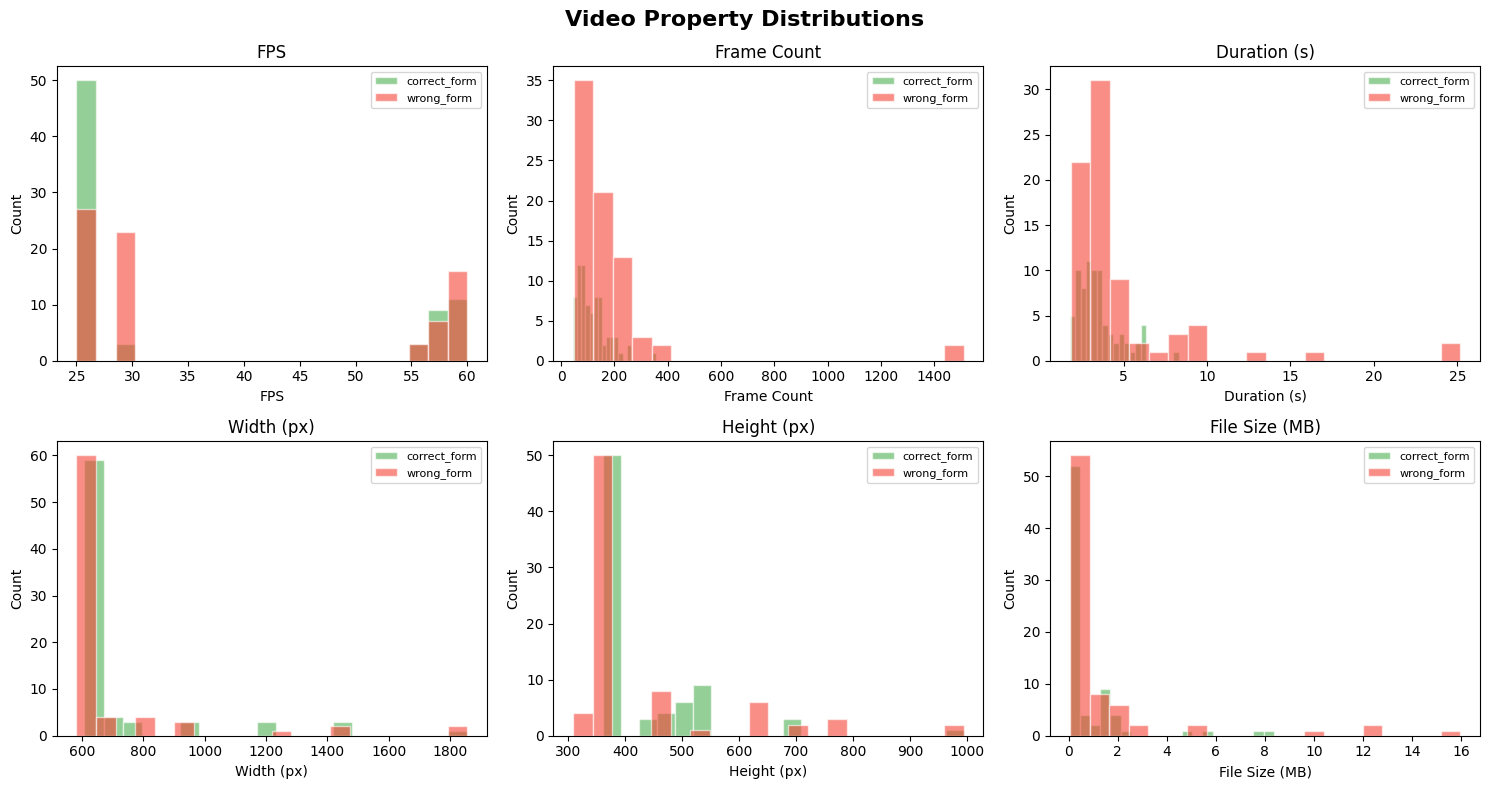

In [62]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Video Property Distributions', fontsize=16, fontweight='bold')

props = [
    ('fps',          'FPS',           'skyblue'),
    ('frame_count',  'Frame Count',   'lightgreen'),
    ('duration_sec', 'Duration (s)',  'salmon'),
    ('width',        'Width (px)',    'plum'),
    ('height',       'Height (px)',   'wheat'),
    ('file_size_mb', 'File Size (MB)','lightcoral'),
]

for ax, (col, title, color) in zip(axes.flat, props):
    for label, grp_color in [('correct_form', '#4CAF50'), ('wrong_form', '#F44336')]:
        subset = df[df['label'] == label][col].dropna()
        ax.hist(subset, bins=20, alpha=0.6, color=grp_color, label=label, edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel(title)
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [63]:
# Unique resolutions
print('Unique resolutions:')
print(df['resolution'].value_counts())

Unique resolutions:
resolution
640x360     100
608x528       9
682x472       6
596x620       6
1464x694      5
798x308       4
1214x512      3
922x502       3
768x432       3
1856x994      3
902x454       3
596x782       3
680x470       2
582x470       1
1240x540      1
Name: count, dtype: int64


## 1.3 Sample Frame Visualization

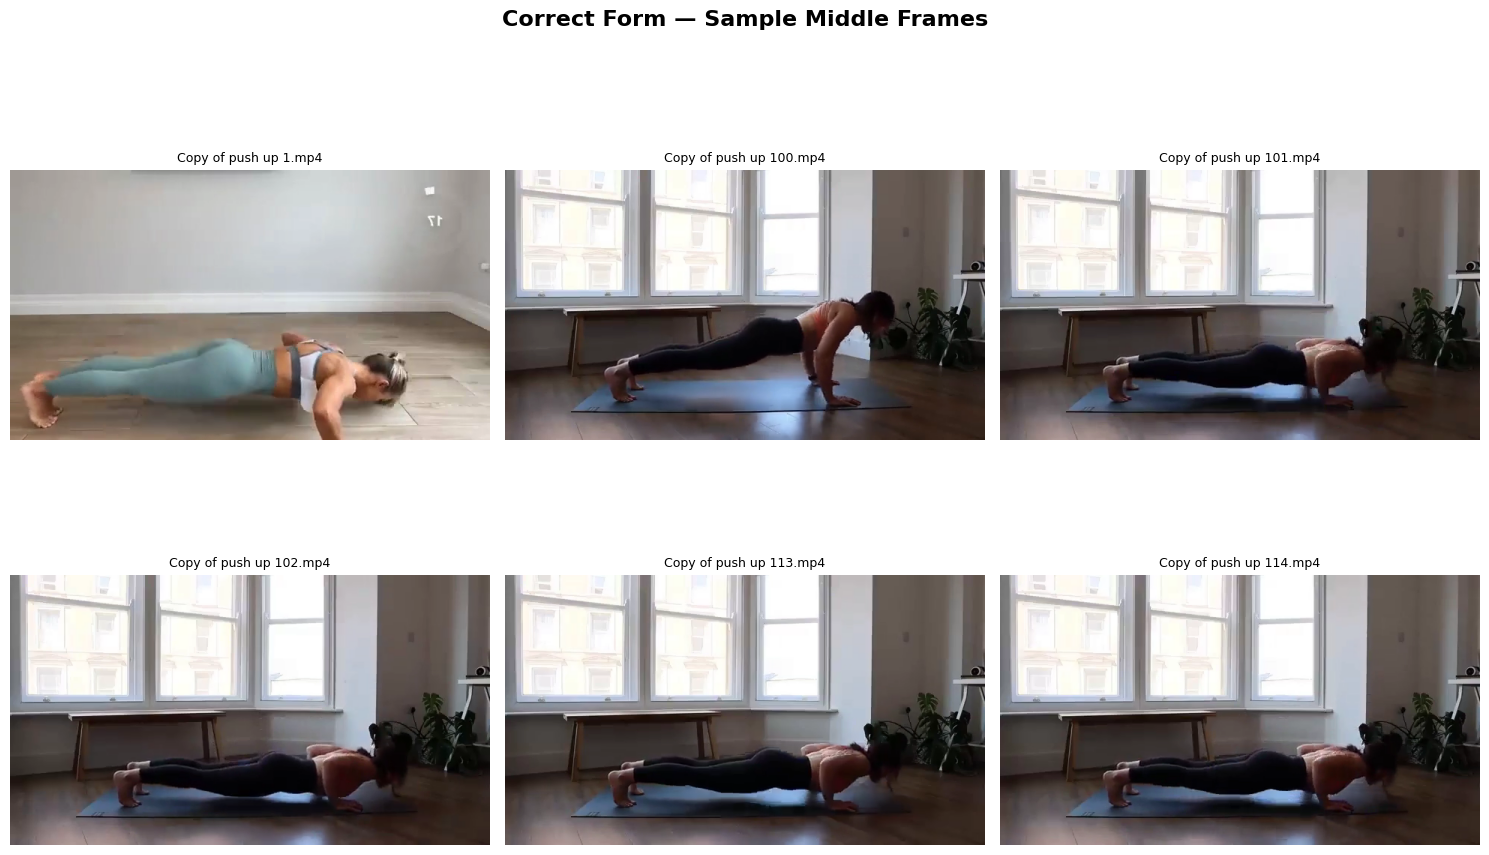

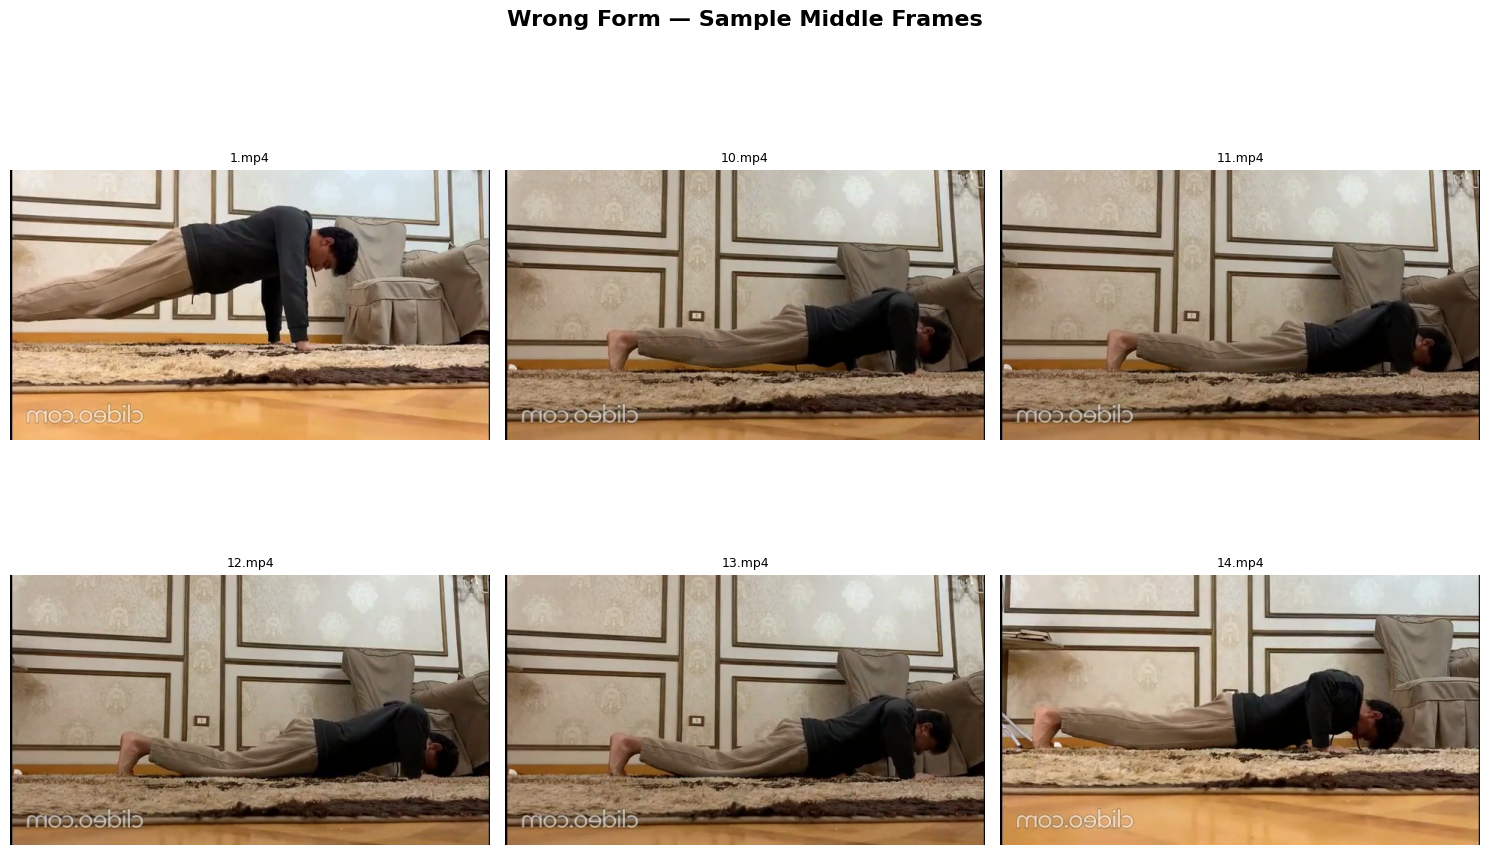

In [64]:
def extract_frame(video_path: str, frame_idx: int = None) -> np.ndarray | None:
    """Extract a single frame (default: middle frame) from a video."""
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return None
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    idx   = frame_idx if frame_idx is not None else total // 2
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ret, frame = cap.read()
    cap.release()
    if ret:
        return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    return None


def show_sample_frames(videos: list[dict], title: str, n: int = 6):
    """Display n sample frames from a list of video records."""
    sample = videos[:n]
    cols   = 3
    rows   = (len(sample) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = np.array(axes).flatten()
    fig.suptitle(title, fontsize=16, fontweight='bold')

    for i, (ax, v) in enumerate(zip(axes, sample)):
        frame = extract_frame(v['path'])
        if frame is not None:
            ax.imshow(frame)
            ax.set_title(v['filename'], fontsize=9)
        else:
            ax.text(0.5, 0.5, 'Could not read', ha='center', va='center')
        ax.axis('off')

    for ax in axes[len(sample):]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()


show_sample_frames(correct_videos, 'Correct Form — Sample Middle Frames', n=6)
show_sample_frames(wrong_videos,   'Wrong Form — Sample Middle Frames',   n=6)

## 1.4 Multi-Frame Strip per Video

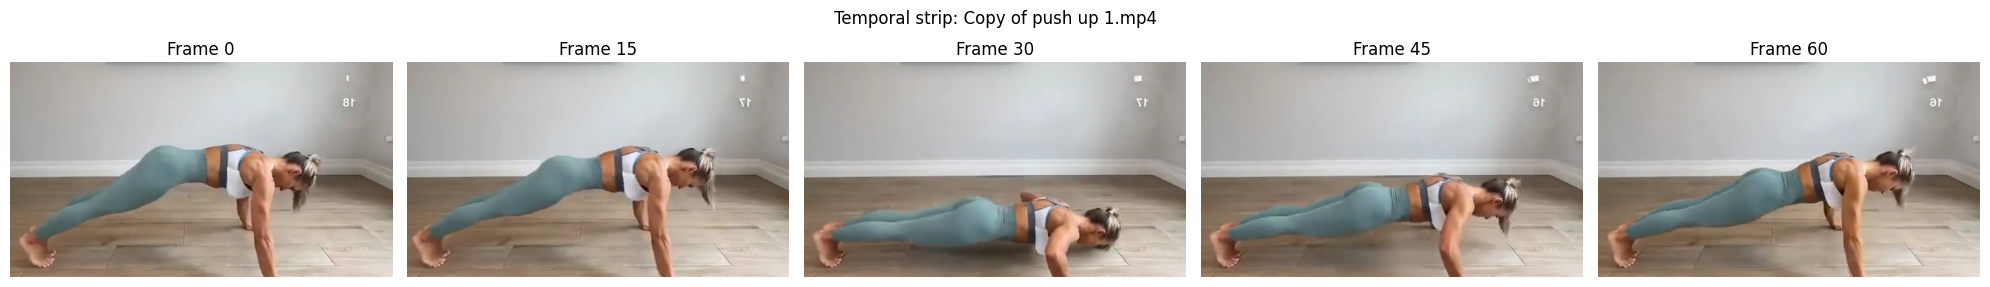

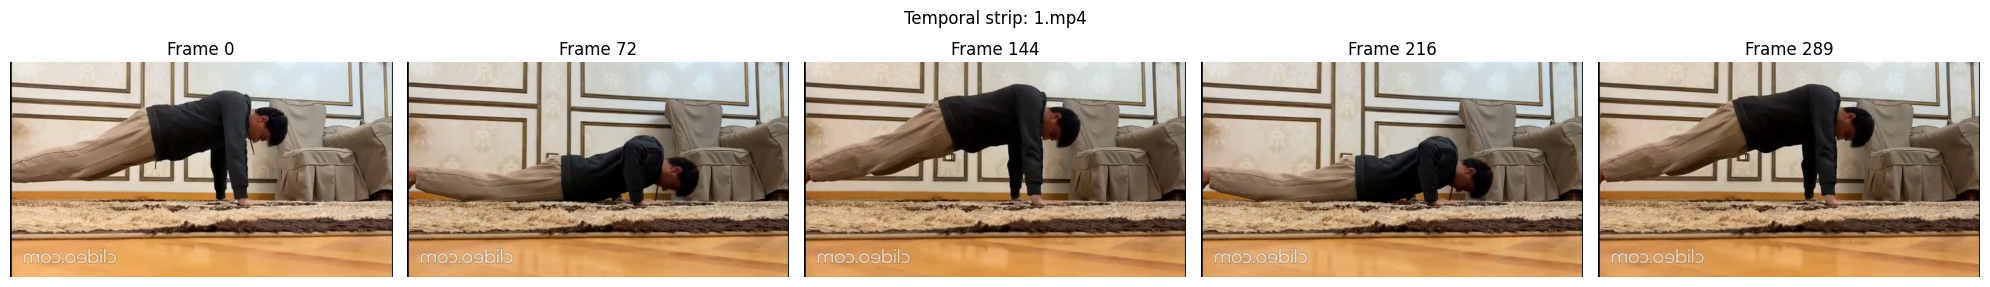

In [65]:
def show_temporal_strip(video_path: str, n_frames: int = 5):
    """Show n evenly-spaced frames from one video."""
    cap   = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    idxs  = np.linspace(0, total - 1, n_frames, dtype=int)

    frames = []
    for idx in idxs:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ret, frame = cap.read()
        if ret:
            frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    cap.release()

    fig, axes = plt.subplots(1, len(frames), figsize=(4 * len(frames), 3))
    name = Path(video_path).name
    fig.suptitle(f'Temporal strip: {name}', fontsize=12)
    for ax, frame, idx in zip(axes, frames, idxs):
        ax.imshow(frame)
        ax.set_title(f'Frame {idx}')
        ax.axis('off')
    plt.tight_layout()
    plt.show()


# Show strip for one correct and one wrong video
show_temporal_strip(correct_videos[0]['path'], n_frames=5)
show_temporal_strip(wrong_videos[0]['path'],   n_frames=5)

## 1.5 Key Findings Summary

In [66]:
print('=== KEY FINDINGS ===')
print(f"Total videos         : {len(all_videos)}")
print(f"  correct_form       : {len(correct_videos)}")
print(f"  wrong_form         : {len(wrong_videos)}")
print(f"Avg duration (s)     : {df['duration_sec'].mean():.2f}")
print(f"Avg FPS              : {df['fps'].mean():.2f}")
print(f"Avg frames per video : {df['frame_count'].mean():.0f}")
print(f"Resolutions          : {df['resolution'].unique().tolist()}")
total_frames_estimate = int(df['frame_count'].sum())
print(f"Total frames (est.)  : {total_frames_estimate:,}")
print()
print('Next step → 2.data_preparation.ipynb: extract frames & build YOLO dataset.')

=== KEY FINDINGS ===
Total videos         : 152
  correct_form       : 76
  wrong_form         : 76
Avg duration (s)     : 4.15
Avg FPS              : 36.57
Avg frames per video : 151
Resolutions          : ['640x360', '608x528', '1464x694', '1214x512', '922x502', '768x432', '1856x994', '682x472', '902x454', '798x308', '680x470', '582x470', '596x782', '596x620', '1240x540']
Total frames (est.)  : 22,905

Next step → 2.data_preparation.ipynb: extract frames & build YOLO dataset.
